# Projet 2 — Données cartographiques concernant l'épidémie de COVID-19

Ce projet consiste à créer des cartes à partir de données cartographiques de l'épidémie de la COVID-19.

L'objectif est de consolider l'information et de la rendre disponible dans des formats ouverts et aisément réutilisables pour produire des cartes. Le format pivot privilégié est le GeoJSON.

Les données sont proposées selon plusieurs granularités : **régions** et **départements**.

- Source principale : https://www.data.gouv.fr/fr/datasets/donnees-cartographiques-concernant-lepidemie-de-covid-19/
- Dépôt GitHub : https://github.com/kalisio/covid-19

---

## Étape 1 — Récupération et exploration des données

### 1.1 — Imports et configuration

In [16]:
import re
import io
import json
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Afficher toutes les colonnes
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)

# URL de base du dépôt GitHub (raw)
BASE_URL = 'https://raw.githubusercontent.com/kalisio/covid-19/master'
API_URL = 'https://api.github.com/repos/kalisio/covid-19/contents'

print('Imports OK — GeoPandas', gpd.__version__)

Imports OK — GeoPandas 1.1.3


### 1.2 — Téléchargement des fichiers GeoJSON de frontières géographiques

Le dépôt contient plusieurs fichiers de contours :
- `regions-france.geojson` → contours des **régions** métropolitaines
- `departements-france.geojson` → contours des **départements** métropolitains
- Variantes avec outre-mer (`outre-mer`), résolutions différentes (`100m`, `500m`)

In [17]:
def telecharger_geojson(nom_fichier):
    """Télécharge et charge un fichier GeoJSON depuis le dépôt kalisio/covid-19."""
    url = f'{BASE_URL}/{nom_fichier}'
    print(f'Téléchargement : {url}')
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    gdf = gpd.read_file(io.BytesIO(response.content))
    print(f'  → {len(gdf)} entités chargées')
    return gdf


# Contours géographiques (mailles statiques)
gdf_regions = telecharger_geojson('regions-france.geojson')
gdf_departements = telecharger_geojson('departements-france.geojson')

Téléchargement : https://raw.githubusercontent.com/kalisio/covid-19/master/regions-france.geojson
  → 13 entités chargées
Téléchargement : https://raw.githubusercontent.com/kalisio/covid-19/master/departements-france.geojson
  → 96 entités chargées


### 1.3 — Téléchargement des données COVID temporelles

Les données COVID sont organisées en deux dossiers, avec **un fichier JSON par date** :
- `regions-france/regions-france-YYYY-MM-DD.json` → données par région
- `departements-france/departements-france-YYYY-MM-DD.json` → données par département

On liste les fichiers disponibles via l'API GitHub, puis on charge tous les fichiers en un seul DataFrame.

In [18]:
def lister_fichiers_github(dossier):
    """Liste les fichiers JSON présents dans un dossier du dépôt via l'API GitHub."""
    url = f'{API_URL}/{dossier}'
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    fichiers = response.json()
    return [
        f['download_url']
        for f in fichiers
        if f['name'].endswith('.json')
    ]


def extraire_date(url):
    """Extrait la date (YYYY-MM-DD) depuis le nom de fichier dans l'URL."""
    match = re.search(r'(\d{4}-\d{2}-\d{2})', url)
    return match.group(1) if match else None


def charger_tous_fichiers(dossier, maille_label):
    """
    Charge l'ensemble des fichiers JSON d'un dossier en un seul GeoDataFrame.
    Ajoute une colonne 'date' et une colonne 'maille'.
    """
    urls = lister_fichiers_github(dossier)
    print(f'{len(urls)} fichiers trouvés dans "{dossier}"')

    gdfs = []
    for url in urls:
        date = extraire_date(url)
        try:
            response = requests.get(url, timeout=30)
            response.raise_for_status()
            gdf = gpd.read_file(io.BytesIO(response.content))
            gdf['date'] = pd.to_datetime(date)
            gdf['maille'] = maille_label
            gdfs.append(gdf)
        except Exception as e:
            print(f'  Erreur sur {url} : {e}')

    if gdfs:
        return gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True))
    return gpd.GeoDataFrame()


print('Chargement des données régions...')
gdf_covid_regions = charger_tous_fichiers('regions-france', 'region')

print('\nChargement des données départements...')
gdf_covid_dept = charger_tous_fichiers('departements-france', 'departement')

print(f'\n✓ Régions  : {len(gdf_covid_regions):,} lignes')
print(f'✓ Depts    : {len(gdf_covid_dept):,} lignes')

Chargement des données régions...
746 fichiers trouvés dans "regions-france"

Chargement des données départements...
746 fichiers trouvés dans "departements-france"

✓ Régions  : 13,428 lignes
✓ Depts    : 75,346 lignes


### 1.4 — Exploration de la structure

#### Fichiers de contours géographiques

In [19]:
print('=== Contours RÉGIONS ===')
print(f'Forme          : {gdf_regions.shape}')
print(f'CRS            : {gdf_regions.crs}')
print(f'Colonnes       : {list(gdf_regions.columns)}')
print()
display(gdf_regions.head(3))

=== Contours RÉGIONS ===
Forme          : (13, 3)
CRS            : EPSG:4326
Colonnes       : ['code', 'nom', 'geometry']



,code,nom,geometry
0,11,Île-de-France,"POLYGON ((2.59052 49.07965, 2.63327 49.10838, 2.67315 49..."
1,24,Centre-Val de Loire,"POLYGON ((2.87463 47.52042, 2.88845 47.50943, 2.90267 47..."
2,27,Bourgogne-Franche-Comté,"POLYGON ((3.62942 46.74946, 3.57569 46.74952, 3.598 46.7..."


In [20]:
print('=== Contours DÉPARTEMENTS ===')
print(f'Forme          : {gdf_departements.shape}')
print(f'CRS            : {gdf_departements.crs}')
print(f'Colonnes       : {list(gdf_departements.columns)}')
print()
display(gdf_departements.head(5))

=== Contours DÉPARTEMENTS ===
Forme          : (96, 3)
CRS            : EPSG:4326
Colonnes       : ['code', 'nom', 'geometry']



,code,nom,geometry
0,01,Ain,"POLYGON ((4.78021 46.17668, 4.79458 46.21832, 4.80776 46..."
1,02,Aisne,"POLYGON ((4.04797 49.40564, 4.03991 49.3974, 4.0355 49.3..."
2,03,Allier,"POLYGON ((3.03207 46.79491, 3.04907 46.75808, 3.08394 46..."
3,04,Alpes-de-Haute-Provence,"POLYGON ((5.67604 44.19143, 5.69209 44.18648, 5.71391 44..."
4,05,Hautes-Alpes,"POLYGON ((6.26057 45.12685, 6.29922 45.10855, 6.3313 45...."


#### Données COVID temporelles — maille Région

In [21]:
print('=== Données COVID — RÉGIONS ===')
print(f'Forme          : {gdf_covid_regions.shape}')
print(f'CRS            : {gdf_covid_regions.crs}')
print(f'Colonnes       : {list(gdf_covid_regions.columns)}')
print(f'Types de données :')
print(gdf_covid_regions.dtypes)
print()
display(gdf_covid_regions.head(3))

=== Données COVID — RÉGIONS ===
Forme          : (13428, 17)
CRS            : EPSG:4326
Colonnes       : ['Country/Region', 'Province/State', 'Code', 'Population', 'Beds', 'Confirmed', 'Emergencies', 'MedicalActs', 'geometry', 'date', 'maille', 'Recovered', 'Severe', 'Critical', 'Deaths', 'MedicalTests', 'PCRTests']
Types de données :
Country/Region               str
Province/State               str
Code                         str
Population                object
Beds                      object
Confirmed                float64
Emergencies               object
MedicalActs               object
geometry                geometry
date              datetime64[us]
maille                       str
Recovered                float64
Severe                   float64
Critical                 float64
Deaths                   float64
MedicalTests              object
PCRTests                  object
dtype: object



,Country/Region,Province/State,Code,Population,Beds,Confirmed,Emergencies,MedicalActs,geometry,date,maille,Recovered,Severe,Critical,Deaths,MedicalTests,PCRTests
0,France,Île-de-France,11,"{'Total': 12278210, 'Under19': 3140965, 'Under39': 34097...","{'Resuscitation': 1147, 'IntensiveCare': 2512, 'Total': ...",NaN,{'Total': 6598},{'Total': 2586},POINT (2.52926 48.70442),2020-03-01,region,NaN,NaN,NaN,NaN,NaN,NaN
1,France,Centre-Val de Loire,24,"{'Total': 2559073, 'Under19': 598570, 'Under39': 541141,...","{'Resuscitation': 180, 'IntensiveCare': 346, 'Total': 526}",NaN,{'Total': 1417},{'Total': 485},POINT (1.64297 47.54357),2020-03-01,region,NaN,NaN,NaN,NaN,NaN,NaN
2,France,Bourgogne-Franche-Comté,27,"{'Total': 2783039, 'Under19': 627017, 'Under39': 591411,...","{'Resuscitation': 198, 'IntensiveCare': 642, 'Total': 840}",10.0,"{'Suspected': 7, 'Total': 2036, 'Severe': 7}",{'Total': 449},POINT (4.73141 47.29692),2020-03-01,region,NaN,NaN,NaN,NaN,NaN,NaN


#### Données COVID temporelles — maille Département

In [22]:
print('=== Données COVID — DÉPARTEMENTS ===')
print(f'Forme          : {gdf_covid_dept.shape}')
print(f'CRS            : {gdf_covid_dept.crs}')
print(f'Colonnes       : {list(gdf_covid_dept.columns)}')
print(f'Types de données :')
print(gdf_covid_dept.dtypes)
print()
display(gdf_covid_dept.head(3))

=== Données COVID — DÉPARTEMENTS ===
Forme          : (75346, 17)
CRS            : EPSG:4326
Colonnes       : ['Country/Region', 'Province/State', 'Code', 'Population', 'Beds', 'Emergencies', 'MedicalActs', 'geometry', 'date', 'maille', 'Confirmed', 'Recovered', 'Deaths', 'Critical', 'MedicalTests', 'Severe', 'PCRTests']
Types de données :
Country/Region               str
Province/State               str
Code                         str
Population                object
Beds                      object
Emergencies               object
MedicalActs               object
geometry                geometry
date              datetime64[us]
maille                       str
Confirmed                float64
Recovered                float64
Deaths                   float64
Critical                 float64
MedicalTests              object
Severe                   float64
PCRTests                  object
dtype: object



,Country/Region,Province/State,Code,Population,Beds,Emergencies,MedicalActs,geometry,date,maille,Confirmed,Recovered,Deaths,Critical,MedicalTests,Severe,PCRTests
0,France,Guadeloupe,971,"{'Total': 376879, 'Under19': 90617, 'Under39': 71707, 'U...","{'Resuscitation': 27, 'IntensiveCare': 68, 'Total': 95}",{'Total': 229},NaN,POINT (-61.49385 16.2047),2020-03-01,departement,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,France,Martinique,972,"{'Total': 358749, 'Under19': 77005, 'Under39': 65776, 'U...","{'Resuscitation': 26, 'IntensiveCare': 58, 'Total': 84}",NaN,{'Total': 114},POINT (-60.98266 14.62176),2020-03-01,departement,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,France,Guyane,973,"{'Total': 290691, 'Under19': 120681, 'Under39': 80023, '...","{'Resuscitation': 13, 'IntensiveCare': 12, 'Total': 25}",{'Total': 238},NaN,POINT (-53.41731 3.5889),2020-03-01,departement,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Plages de dates disponibles

In [23]:
dates_regions = sorted(gdf_covid_regions['date'].unique())
dates_dept = sorted(gdf_covid_dept['date'].unique())

print('=== Plages de dates ===')
print(f'Régions     : {len(dates_regions)} dates'
      f' | de {min(dates_regions).strftime("%Y-%m-%d")}'
      f' à {max(dates_regions).strftime("%Y-%m-%d")}')
print(f'Départements: {len(dates_dept)} dates'
      f' | de {min(dates_dept).strftime("%Y-%m-%d")}'
      f' à {max(dates_dept).strftime("%Y-%m-%d")}')

=== Plages de dates ===
Régions     : 373 dates | de 2020-03-01 à 2021-03-08
Départements: 373 dates | de 2020-03-01 à 2021-03-08


#### Valeurs statistiques descriptives

In [24]:
# Colonnes numériques uniquement
cols_num_regions = gdf_covid_regions.select_dtypes(include='number').columns.tolist()
cols_num_dept = gdf_covid_dept.select_dtypes(include='number').columns.tolist()

print('Colonnes numériques — Régions :', cols_num_regions)
display(gdf_covid_regions[cols_num_regions].describe().round(1))

print('\nColonnes numériques — Départements :', cols_num_dept)
display(gdf_covid_dept[cols_num_dept].describe().round(1))

Colonnes numériques — Régions : ['Confirmed', 'Recovered', 'Severe', 'Critical', 'Deaths']


,Confirmed,Recovered,Severe,Critical,Deaths
count,13326.0,12860.0,12726.0,12476.0,12770.0
mean,1617.7,6419.9,987.0,136.8,1537.8
std,1937.0,10307.2,1582.8,246.1,2480.0
min,1.0,1.0,1.0,1.0,1.0
25%,128.0,492.0,49.0,8.0,59.0
50%,1007.0,2252.5,334.0,36.0,499.0
75%,2093.0,7566.0,1246.8,173.0,1801.0
max,7660.0,68145.0,13209.0,2668.0,15355.0



Colonnes numériques — Départements : ['Confirmed', 'Recovered', 'Deaths', 'Critical', 'Severe']


,Confirmed,Recovered,Deaths,Critical,Severe
count,69004.0,71666.0,71382.0,62732.0,70388.0
mean,112.7,1152.4,275.1,27.2,178.4
std,148.8,1778.9,411.4,48.5,270.8
min,1.0,1.0,1.0,1.0,1.0
25%,22.0,175.0,40.0,4.0,22.0
50%,55.0,504.0,110.0,10.0,78.0
75%,128.0,1243.0,307.0,29.0,214.0
max,827.0,15163.0,3321.0,855.0,3281.0


### 1.5 — Nettoyage des données

On identifie et traite les valeurs manquantes ainsi que les incohérences potentielles.

In [25]:
def rapport_valeurs_manquantes(gdf, label):
    """Affiche le rapport des valeurs manquantes pour un GeoDataFrame."""
    total = len(gdf)
    manquants = gdf.isnull().sum()
    pct = (manquants / total * 100).round(2)
    rapport = pd.DataFrame({
        'Nb manquants': manquants,
        'Pourcentage (%)': pct
    })
    rapport = rapport[rapport['Nb manquants'] > 0].sort_values(
        'Nb manquants', ascending=False
    )
    if rapport.empty:
        print(f'{label} : aucune valeur manquante ✓')
    else:
        print(f'{label} ({total} lignes) — valeurs manquantes :')
        display(rapport)


rapport_valeurs_manquantes(gdf_covid_regions, 'COVID Régions')
print()
rapport_valeurs_manquantes(gdf_covid_dept, 'COVID Départements')

COVID Régions (13428 lignes) — valeurs manquantes :


,Nb manquants,Pourcentage (%)
MedicalActs,2984,22.22
PCRTests,2628,19.57
MedicalTests,1184,8.82
Critical,952,7.09
Emergencies,746,5.56
Severe,702,5.23
Deaths,658,4.90
Recovered,568,4.23
Confirmed,102,0.76



COVID Départements (75346 lignes) — valeurs manquantes :


,Nb manquants,Pourcentage (%)
MedicalActs,41030,54.46
PCRTests,14746,19.57
Critical,12614,16.74
Confirmed,6342,8.42
Severe,4958,6.58
MedicalTests,4172,5.54
Deaths,3964,5.26
Recovered,3680,4.88
Emergencies,746,0.99


In [26]:
def nettoyer_gdf(gdf, maille_label):
    """
    Nettoie un GeoDataFrame de données COVID :
    - Supprime les géométries nulles ou invalides
    - Remplace les NaN numériques par 0 (données manquantes = 0 cas)
    - Vérifie les valeurs négatives incohérentes
    """
    n_initial = len(gdf)

    # 1) Suppression des géométries nulles
    gdf = gdf[gdf.geometry.notna()].copy()
    n_apres_geo = len(gdf)
    if n_initial != n_apres_geo:
        print(f'  [{maille_label}] {n_initial - n_apres_geo} géométries nulles supprimées')

    # 2) Colonnes numériques : remplacement des NaN par 0
    cols_num = gdf.select_dtypes(include='number').columns.tolist()
    nb_nan_avant = gdf[cols_num].isnull().sum().sum()
    gdf[cols_num] = gdf[cols_num].fillna(0)
    if nb_nan_avant > 0:
        print(f'  [{maille_label}] {nb_nan_avant} NaN numériques remplacés par 0')

    # 3) Détection des valeurs négatives
    for col in cols_num:
        nb_negatifs = (gdf[col] < 0).sum()
        if nb_negatifs > 0:
            print(f'  [{maille_label}] ⚠ Colonne "{col}" : {nb_negatifs} valeurs négatives')
            gdf[col] = gdf[col].clip(lower=0)  # on force à 0

    print(f'  [{maille_label}] Nettoyage terminé : {len(gdf):,} lignes conservées')
    return gdf


print('Nettoyage des données COVID...')
gdf_covid_regions = nettoyer_gdf(gdf_covid_regions, 'Régions')
gdf_covid_dept = nettoyer_gdf(gdf_covid_dept, 'Départements')
print('\nNettoyage terminé ✓')

Nettoyage des données COVID...
  [Régions] 2982 NaN numériques remplacés par 0
  [Régions] Nettoyage terminé : 13,428 lignes conservées
  [Départements] 31558 NaN numériques remplacés par 0
  [Départements] Nettoyage terminé : 75,346 lignes conservées

Nettoyage terminé ✓


### 1.6 — Vérification de la cohérence et résumé

#### Nombre d'entités par date (validation)

In [27]:
entites_par_date_regions = gdf_covid_regions.groupby('date').size()
entites_par_date_dept = gdf_covid_dept.groupby('date').size()

print('Entités par date — Régions (quelques dates) :')
display(entites_par_date_regions.describe().to_frame('nb_entités').T.round(1))

print('\nEntités par date — Départements (quelques dates) :')
display(entites_par_date_dept.describe().to_frame('nb_entités').T.round(1))

# Dates avec un nombre inhabituel d'entités
mode_regions = entites_par_date_regions.mode()[0]
mode_dept = entites_par_date_dept.mode()[0]

anomalies_regions = entites_par_date_regions[entites_par_date_regions != mode_regions]
anomalies_dept = entites_par_date_dept[entites_par_date_dept != mode_dept]

if anomalies_regions.empty:
    print(f'\n✓ Régions : {mode_regions} entités par date de façon homogène')
else:
    print(f'\n⚠ Régions : dates avec un nombre d\'entités différent de {mode_regions} :')
    display(anomalies_regions)

if anomalies_dept.empty:
    print(f'✓ Depts   : {mode_dept} entités par date de façon homogène')
else:
    print(f'⚠ Depts   : dates avec un nombre d\'entités différent de {mode_dept} :')
    display(anomalies_dept)

Entités par date — Régions (quelques dates) :


,count,mean,std,min,25%,50%,75%,max
nb_entités,373.0,36.0,0.0,36.0,36.0,36.0,36.0,36.0



Entités par date — Départements (quelques dates) :


,count,mean,std,min,25%,50%,75%,max
nb_entités,373.0,202.0,0.0,202.0,202.0,202.0,202.0,202.0



✓ Régions : 36 entités par date de façon homogène
✓ Depts   : 202 entités par date de façon homogène


#### Aperçu des mailles disponibles

In [28]:
# Identification des colonnes identitaires disponibles (nom, code...)
cols_id_regions = [c for c in gdf_covid_regions.columns
                   if any(k in c.lower() for k in ['nom', 'code', 'name', 'id', 'lib'])]
cols_id_dept = [c for c in gdf_covid_dept.columns
                if any(k in c.lower() for k in ['nom', 'code', 'name', 'id', 'lib'])]

sample_date_r = gdf_covid_regions['date'].max()
sample_date_d = gdf_covid_dept['date'].max()

print(f'Mailles RÉGIONS (dernier snapshot : {sample_date_r.date()}) :')
display(gdf_covid_regions[gdf_covid_regions['date'] == sample_date_r][cols_id_regions].head(13))

print(f'\nMailles DÉPARTEMENTS (dernier snapshot : {sample_date_d.date()}) :')
display(gdf_covid_dept[gdf_covid_dept['date'] == sample_date_d][cols_id_dept].head(10))

Mailles RÉGIONS (dernier snapshot : 2021-03-08) :


,Code
6696,11
6697,24
6698,27
6699,28
6700,32
6701,44
6702,52
6703,53
6704,75
6705,76



Mailles DÉPARTEMENTS (dernier snapshot : 2021-03-08) :


,Code
37572,971
37573,972
37574,973
37575,976
37576,01
37577,02
37578,03
37579,04
37580,05
37581,06


### 1.7 — Visualisation rapide des contours géographiques

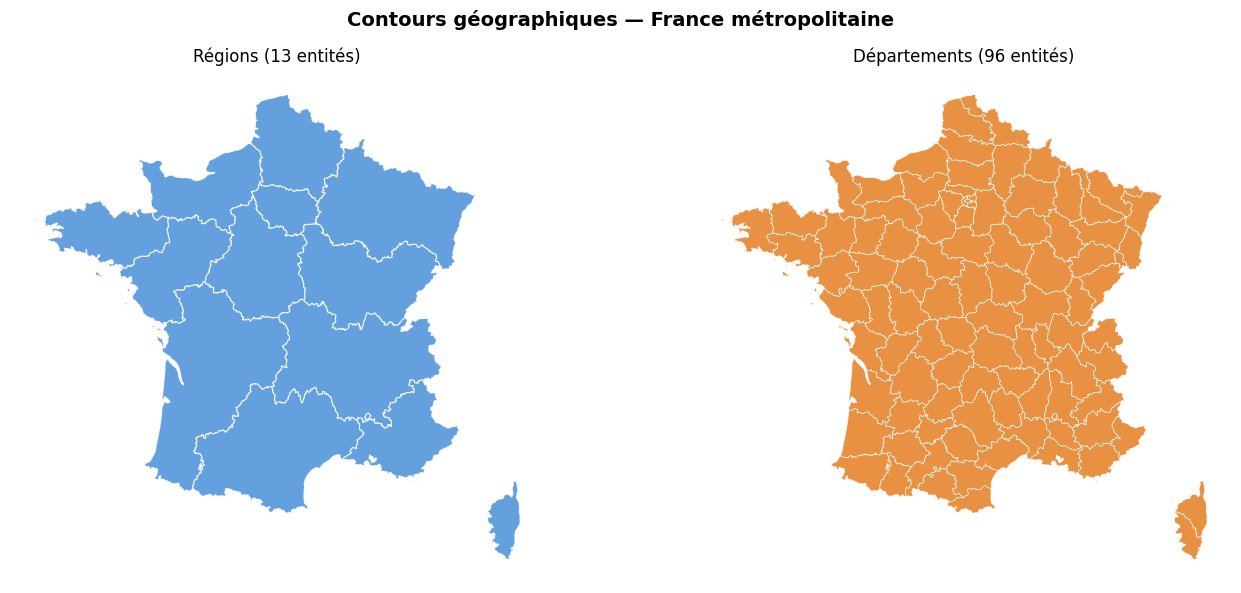

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Contours géographiques — France métropolitaine', fontsize=14, fontweight='bold')

gdf_regions.plot(ax=axes[0], color='#4A90D9', edgecolor='white', linewidth=0.8, alpha=0.85)
axes[0].set_title(f'Régions ({len(gdf_regions)} entités)', fontsize=12)
axes[0].axis('off')

gdf_departements.plot(ax=axes[1], color='#E67E22', edgecolor='white', linewidth=0.5, alpha=0.85)
axes[1].set_title(f'Départements ({len(gdf_departements)} entités)', fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.show()

### 1.8 — Résumé de l'Étape 1

In [30]:
print('=' * 60)
print('RÉSUMÉ — ÉTAPE 1 : Récupération et exploration des données')
print('=' * 60)

print('\n📦 Fichiers GeoJSON chargés :')
print(f'  • regions-france.geojson     : {len(gdf_regions)} régions')
print(f'  • departements-france.geojson: {len(gdf_departements)} départements')

print('\n📅 Données COVID temporelles :')
print(f'  • Régions     : {len(gdf_covid_regions):,} lignes | '
      f'{len(dates_regions)} dates | '
      f'{min(dates_regions).strftime("%d/%m/%Y")} → {max(dates_regions).strftime("%d/%m/%Y")}')
print(f'  • Départements: {len(gdf_covid_dept):,} lignes | '
      f'{len(dates_dept)} dates | '
      f'{min(dates_dept).strftime("%d/%m/%Y")} → {max(dates_dept).strftime("%d/%m/%Y")}')

print('\n🗂 Colonnes de données COVID (régions) :')
cols_data = [c for c in gdf_covid_regions.columns
             if c not in ['geometry', 'date', 'maille']]
for col in cols_data:
    dtype = gdf_covid_regions[col].dtype
    print(f'  • {col} ({dtype})')

print('\n✅ Nettoyage effectué :')
print('  • Géométries nulles supprimées')
print('  • NaN numériques remplacés par 0')
print('  • Valeurs négatives corrigées (clip à 0)')
print('\nDonnées prêtes pour l\'Étape 2 (clustering + visualisation cartographique).')
print('=' * 60)

RÉSUMÉ — ÉTAPE 1 : Récupération et exploration des données

📦 Fichiers GeoJSON chargés :
  • regions-france.geojson     : 13 régions
  • departements-france.geojson: 96 départements

📅 Données COVID temporelles :
  • Régions     : 13,428 lignes | 373 dates | 01/03/2020 → 08/03/2021
  • Départements: 75,346 lignes | 373 dates | 01/03/2020 → 08/03/2021

🗂 Colonnes de données COVID (régions) :
  • Country/Region (str)
  • Province/State (str)
  • Code (str)
  • Population (object)
  • Beds (object)
  • Confirmed (float64)
  • Emergencies (object)
  • MedicalActs (object)
  • Recovered (float64)
  • Severe (float64)
  • Critical (float64)
  • Deaths (float64)
  • MedicalTests (object)
  • PCRTests (object)

✅ Nettoyage effectué :
  • Géométries nulles supprimées
  • NaN numériques remplacés par 0
  • Valeurs négatives corrigées (clip à 0)

Données prêtes pour l'Étape 2 (clustering + visualisation cartographique).


---
## Étape 2 — Préparation des features pour le clustering

### 2.1 — Extraction et aplatissement des colonnes imbriquées

Les propriétés JSON contiennent des objets **imbriqués** (`Population`, `Beds`, `Emergencies`, `MedicalTests`).
GeoPandas les charge comme `dict` Python ; on les aplatit.

In [31]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression


def aplatir_colonne_dict(gdf, col):
    """Extrait les sous-clés d'une colonne contenant des dicts."""
    if col not in gdf.columns:
        return gdf
    mask = gdf[col].apply(lambda v: isinstance(v, dict))
    if not mask.any():
        return gdf
    expanded = gdf.loc[mask, col].apply(pd.Series)
    expanded.columns = [f'{col}_{c}' for c in expanded.columns]
    gdf = gdf.drop(columns=[col])
    gdf = gdf.join(expanded)
    return gdf


def aplatir_gdf(gdf):
    """Aplatit toutes les colonnes de type dict."""
    cols_dict = [
        c for c in gdf.columns
        if gdf[c].apply(lambda v: isinstance(v, dict)).any()
    ]
    for col in cols_dict:
        gdf = aplatir_colonne_dict(gdf, col)
    return gdf


gdf_dept_flat = aplatir_gdf(gdf_covid_dept.copy())
gdf_reg_flat = aplatir_gdf(gdf_covid_regions.copy())

print('Colonnes après aplatissement — Départements :')
print(sorted(gdf_dept_flat.columns.tolist()))

Colonnes après aplatissement — Départements :
['Beds_IntensiveCare', 'Beds_Resuscitation', 'Beds_Total', 'Code', 'Confirmed', 'Country/Region', 'Critical', 'Deaths', 'Emergencies_Severe', 'Emergencies_Severe/Accumulated', 'Emergencies_Suspected', 'Emergencies_Suspected/Accumulated', 'Emergencies_Total', 'Emergencies_Total/Accumulated', 'MedicalActs_Suspected', 'MedicalActs_Suspected/Accumulated', 'MedicalActs_Total', 'MedicalActs_Total/Accumulated', 'MedicalTests_Confirmed', 'MedicalTests_Confirmed/Accumulated', 'MedicalTests_Total', 'MedicalTests_Total/Accumulated', 'PCRTests_Confirmed', 'PCRTests_Confirmed/Accumulated', 'PCRTests_Total', 'PCRTests_Total/Accumulated', 'Population_Over75', 'Population_Total', 'Population_Under19', 'Population_Under39', 'Population_Under59', 'Population_Under74', 'Province/State', 'Recovered', 'Severe', 'date', 'geometry', 'maille']


### 2.2 — Sélection des variables pertinentes

| Feature | Signification |
|---|---|
| `Confirmed` | Cas confirmés |
| `Deaths` | Décès |
| `Recovered` | Guérisons |
| `Severe` | Hospitalisations |
| `Critical` | Soins intensifs |
| `Population_Total` | Population totale |
| `Beds_Total` | Capacité hospitalière |
| `taux_incidence` | Confirmed / Population × 100 000 |
| `taux_hospitalisation` | Severe / Population × 100 000 |
| `taux_mortalite` | Deaths / Confirmed |

In [32]:
COLS_BRUTES = [
    'Confirmed', 'Deaths', 'Recovered', 'Severe', 'Critical',
    'Population_Total', 'Beds_Total',
]


def selectionner_et_enrichir(gdf_flat, maille):
    """Sélectionne les colonnes et calcule les taux dérivés."""
    cols_dispo = [c for c in COLS_BRUTES if c in gdf_flat.columns]
    cols_meta = ['Province/State', 'Code', 'date', 'geometry']
    cols_meta = [c for c in cols_meta if c in gdf_flat.columns]
    df = gdf_flat[cols_meta + cols_dispo].copy()
    df[cols_dispo] = df[cols_dispo].fillna(0)

    pop = df['Population_Total'].replace(0, np.nan)
    conf = df['Confirmed'].replace(0, np.nan)
    df['taux_incidence'] = (df['Confirmed'] / pop * 100_000).fillna(0)
    df['taux_hospitalisation'] = (df['Severe'] / pop * 100_000).fillna(0)
    df['taux_mortalite'] = (df['Deaths'] / conf).fillna(0)
    df['taux_guerison'] = (df['Recovered'] / conf).fillna(0)
    df['occupation_reanimation'] = (
        df['Critical'] / df['Beds_Total'].replace(0, np.nan)
    ).fillna(0)
    print(f'{maille} : {len(df):,} lignes | {len(df.columns)} colonnes')
    return df


df_dept = selectionner_et_enrichir(gdf_dept_flat, 'Départements')
df_reg = selectionner_et_enrichir(gdf_reg_flat, 'Régions')

FEATURES = [
    'Confirmed', 'Deaths', 'Recovered', 'Severe', 'Critical',
    'taux_incidence', 'taux_hospitalisation',
    'taux_mortalite', 'taux_guerison', 'occupation_reanimation',
]
print('\nAperçu des features (départements) :')
display(df_dept[FEATURES].describe().round(2))

Départements : 75,346 lignes | 16 colonnes
Régions : 13,428 lignes | 16 colonnes

Aperçu des features (départements) :


,Confirmed,Deaths,Recovered,Severe,Critical,taux_incidence,taux_hospitalisation,taux_mortalite,taux_guerison,occupation_reanimation
count,75346.00,75346.00,75346.00,75346.00,75346.00,75346.00,75346.00,75346.00,75346.00,75346.00
mean,103.22,260.66,1096.16,166.63,22.62,16.01,22.60,8.16,32.24,0.17
std,145.81,405.09,1752.56,265.46,45.45,19.24,24.01,39.03,146.79,0.27
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,14.00,32.00,147.00,15.00,1.00,3.66,3.90,0.39,1.94,0.02
50%,48.00,100.00,458.00,67.00,7.00,10.14,14.33,1.20,5.93,0.09
75%,126.00,285.00,1171.00,199.00,23.00,21.81,35.37,4.42,18.57,0.22
max,827.00,3321.00,15163.00,3281.00,855.00,127.45,163.40,777.00,2950.00,5.50


### 2.3 — Gestion de la dimension temporelle

Trois stratégies :
- **A — Snapshot** : une date fixe (pic des décès nationaux)
- **B — Moyenne** : indicateurs moyennés sur toute la période
- **C — Tendance** : pente de régression linéaire par département

In [33]:
# --- A : Snapshot au pic national ---
pic_date = df_dept.groupby('date')['Deaths'].sum().idxmax()
print(f'Date du pic national : {pic_date.date()}')

df_snapshot = df_dept[df_dept['date'] == pic_date].copy()
print(f'Snapshot : {len(df_snapshot)} départements')

# --- B : Moyenne sur toute la période ---
df_moyenne = (
    df_dept.groupby('Code')[FEATURES]
    .mean()
    .reset_index()
)
meta_dept = (
    df_dept[df_dept['date'] == df_dept['date'].max()]
    [['Code', 'Province/State', 'geometry']]
    .drop_duplicates('Code')
)
df_moyenne = df_moyenne.merge(meta_dept, on='Code', how='left')
print(f'Moyenne : {len(df_moyenne)} départements')

# --- C : Tendance (pente linéaire) ---
def calculer_pente(serie):
    """Pente de régression linéaire d'une série temporelle."""
    if len(serie) < 2:
        return 0.0
    X = np.arange(len(serie)).reshape(-1, 1)
    return LinearRegression().fit(X, serie.values).coef_[0]


tendances = (
    df_dept.sort_values('date')
    .groupby('Code')
    .apply(
        lambda g: pd.Series({
            'pente_confirmed': calculer_pente(g['Confirmed']),
            'pente_deaths': calculer_pente(g['Deaths']),
            'pente_severe': calculer_pente(g['Severe']),
        }),
        include_groups=False,
    )
    .reset_index()
)
df_tendance = df_moyenne.merge(tendances, on='Code', how='left')
print(f'Tendance calculée : {len(df_tendance)} départements')
display(df_tendance[['Code', 'Province/State',
                      'pente_confirmed', 'pente_deaths']].head(6))

Date du pic national : 2021-03-08
Snapshot : 202 départements
Moyenne : 101 départements
Tendance calculée : 101 départements


,Code,Province/State,pente_confirmed,pente_deaths
0,01,Ain,0.036550,0.644411
1,02,Aisne,0.012246,0.816558
2,03,Allier,0.015332,0.611220
3,04,Alpes-de-Haute-Provence,0.007833,0.217994
4,05,Hautes-Alpes,0.011865,0.266197
5,06,Alpes-Maritimes,0.062598,1.160310


### 2.4 — Normalisation

- **StandardScaler** : μ = 0, σ = 1 → recommandé pour K-Means / DBSCAN
- **MinMaxScaler** : [0, 1] → utile si les features ont des bornes connues

In [34]:
FEATURES_CLUSTER = [
    'taux_incidence',
    'taux_hospitalisation',
    'taux_mortalite',
    'taux_guerison',
    'occupation_reanimation',
]


def normaliser(df, features, methode='standard'):
    """Normalise et retourne (DataFrame_scalé, scaler_fitté)."""
    df_feat = df[features].copy().fillna(0)
    scaler = StandardScaler() if methode == 'standard' else MinMaxScaler()
    X = scaler.fit_transform(df_feat)
    return pd.DataFrame(X, columns=features, index=df.index), scaler


# Snapshot
X_snap_std, scaler_std = normaliser(df_snapshot, FEATURES_CLUSTER, 'standard')
X_snap_mm, scaler_mm = normaliser(df_snapshot, FEATURES_CLUSTER, 'minmax')

# Moyenne
X_moy_std, _ = normaliser(df_moyenne, FEATURES_CLUSTER, 'standard')

print('=== Snapshot — StandardScaler ===')
display(X_snap_std.describe().round(3))
print('\n=== Snapshot — MinMaxScaler ===')
display(X_snap_mm.describe().round(3))

=== Snapshot — StandardScaler ===


,taux_incidence,taux_hospitalisation,taux_mortalite,taux_guerison,occupation_reanimation
count,202.000,202.000,202.000,202.000,202.000
mean,0.000,-0.000,0.000,-0.000,0.000
std,1.002,1.002,1.002,1.002,1.002
min,-0.864,-1.742,-0.262,-0.268,-0.572
25%,-0.635,-0.707,-0.228,-0.232,-0.370
50%,-0.327,-0.064,-0.191,-0.191,-0.210
75%,0.307,0.536,-0.092,-0.095,-0.009
max,5.660,3.785,9.576,9.572,8.266



=== Snapshot — MinMaxScaler ===


,taux_incidence,taux_hospitalisation,taux_mortalite,taux_guerison,occupation_reanimation
count,202.000,202.000,202.000,202.000,202.000
mean,0.132,0.315,0.027,0.027,0.065
std,0.154,0.181,0.102,0.102,0.113
min,0.000,0.000,0.000,0.000,0.000
25%,0.035,0.187,0.003,0.004,0.023
50%,0.082,0.304,0.007,0.008,0.041
75%,0.179,0.412,0.017,0.018,0.064
max,1.000,1.000,1.000,1.000,1.000


### 2.5 — Analyse exploratoire des features

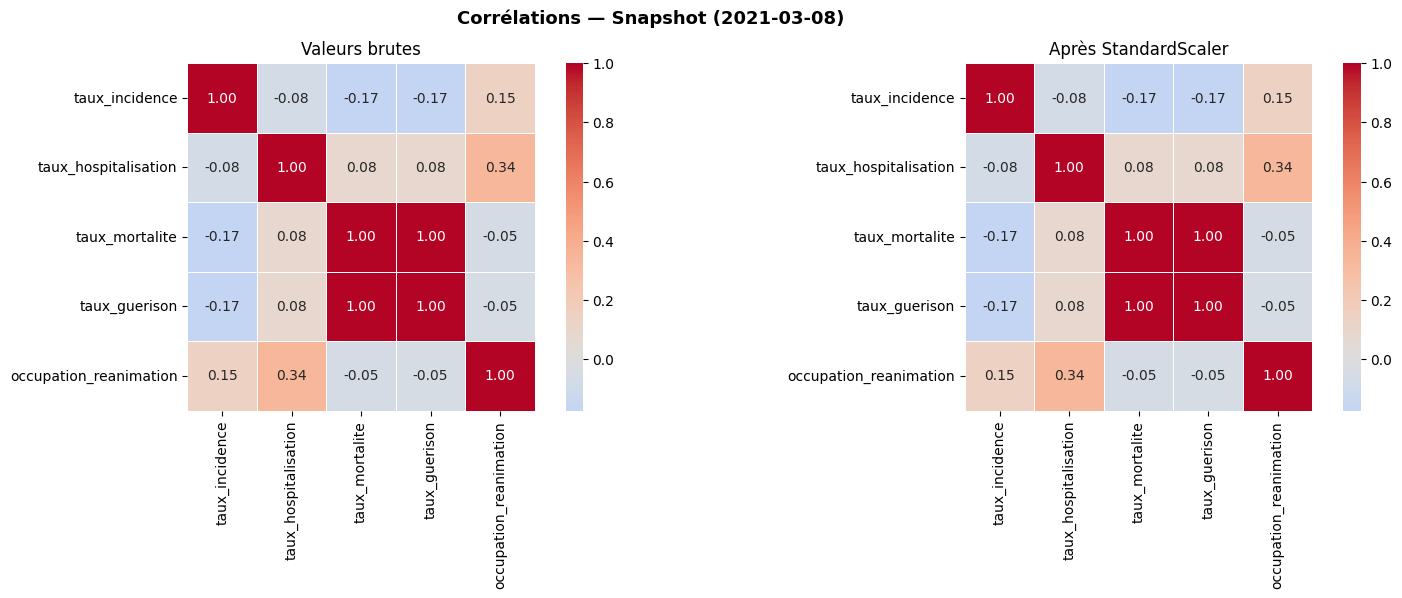

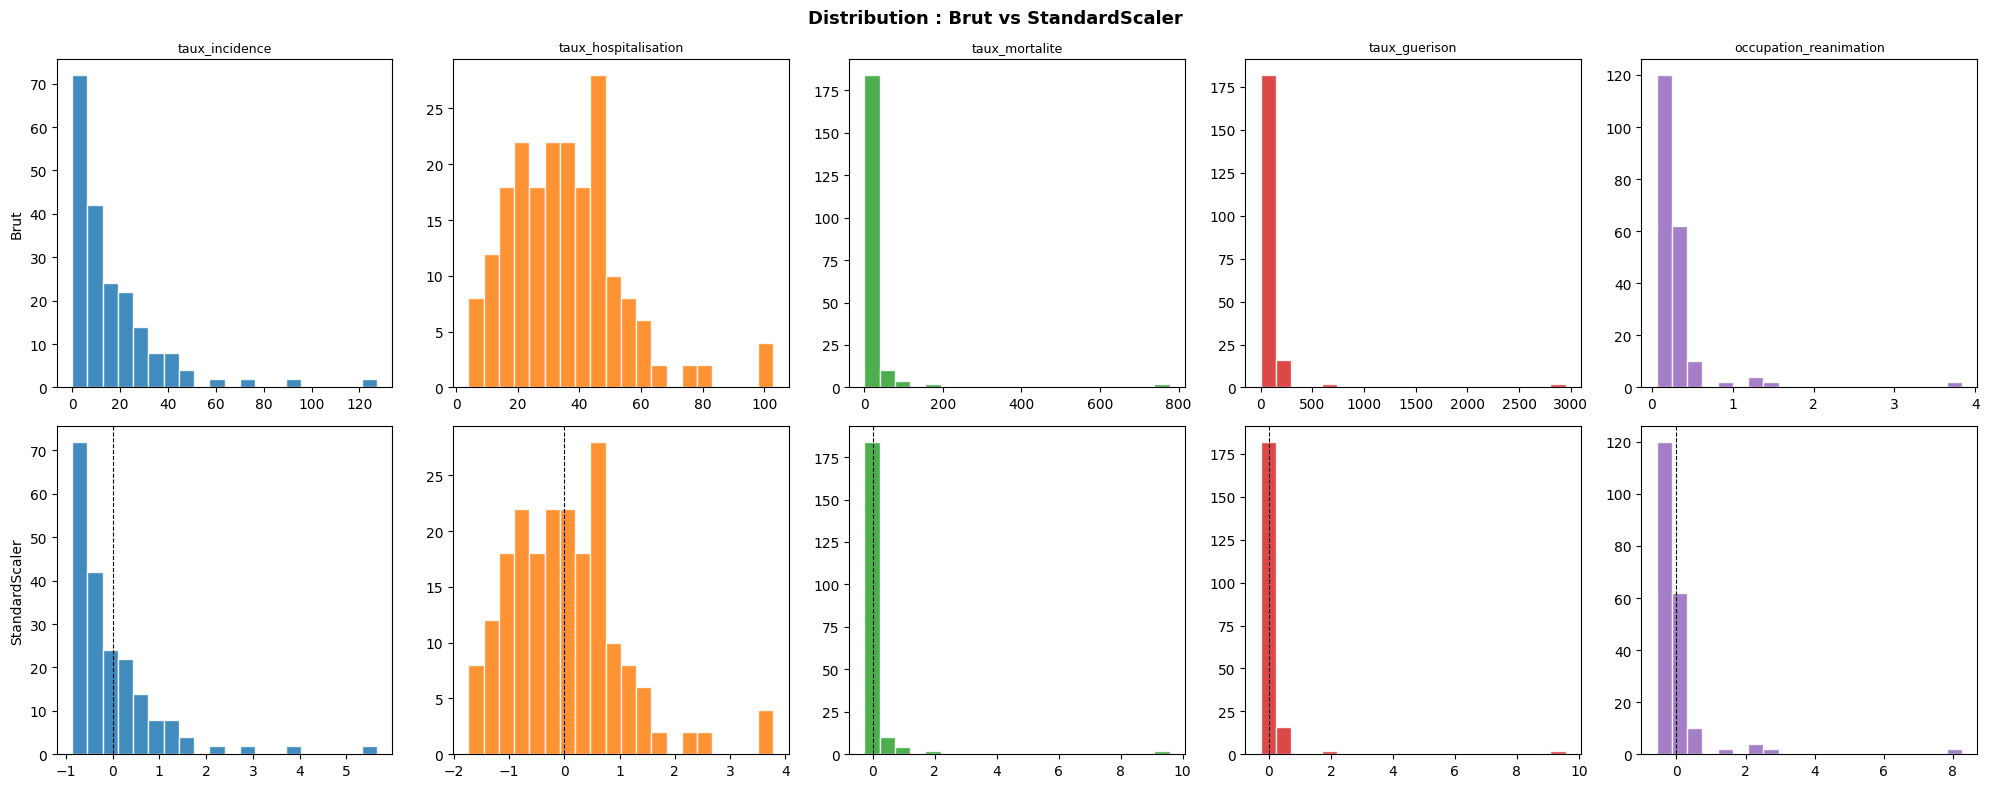

In [35]:
# Matrice de corrélation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    f'Corrélations — Snapshot ({pic_date.date()})',
    fontsize=13, fontweight='bold'
)
sns.heatmap(
    df_snapshot[FEATURES_CLUSTER].fillna(0).corr(),
    annot=True, fmt='.2f', cmap='coolwarm',
    center=0, ax=axes[0], square=True, linewidths=0.5
)
axes[0].set_title('Valeurs brutes')
sns.heatmap(
    X_snap_std.corr(),
    annot=True, fmt='.2f', cmap='coolwarm',
    center=0, ax=axes[1], square=True, linewidths=0.5
)
axes[1].set_title('Après StandardScaler')
plt.tight_layout()
plt.show()

# Distributions brut vs normalisé
n = len(FEATURES_CLUSTER)
fig2, axes2 = plt.subplots(2, n, figsize=(4 * n, 8))
fig2.suptitle('Distribution : Brut vs StandardScaler',
              fontsize=13, fontweight='bold')
colors = plt.cm.tab10.colors
for i, feat in enumerate(FEATURES_CLUSTER):
    axes2[0, i].hist(
        df_snapshot[feat].fillna(0), bins=20,
        color=colors[i], edgecolor='white', alpha=0.85
    )
    axes2[0, i].set_title(feat, fontsize=9)
    if i == 0:
        axes2[0, i].set_ylabel('Brut')
    axes2[1, i].hist(
        X_snap_std[feat], bins=20,
        color=colors[i], edgecolor='white', alpha=0.85
    )
    axes2[1, i].axvline(0, color='black', lw=0.8, ls='--')
    if i == 0:
        axes2[1, i].set_ylabel('StandardScaler')
plt.tight_layout()
plt.show()

### 2.6 — Résumé de l'Étape 2

In [36]:
print('=' * 60)
print('RÉSUMÉ — ÉTAPE 2 : Préparation des features')
print('=' * 60)
print('\n📐 Features retenues pour le clustering :')
for f in FEATURES_CLUSTER:
    print(f'  • {f}')
print('\n📅 Objets disponibles :')
print(f'  A) df_snapshot  → {len(df_snapshot)} depts | pic {pic_date.date()}')
print(f'  B) df_moyenne   → {len(df_moyenne)} depts | moyenne temporelle')
print(f'  C) df_tendance  → {len(df_tendance)} depts | pentes')
print('\n⚖️  Matrices normalisées :')
print(f'  • X_snap_std {X_snap_std.shape}  (StandardScaler)')
print(f'  • X_snap_mm  {X_snap_mm.shape}  (MinMaxScaler)')
print(f'  • X_moy_std  {X_moy_std.shape}  (StandardScaler sur moyenne)')
print('\n➡️  Recommandation : X_snap_std ou X_moy_std pour K-Means / DBSCAN.')
print('=' * 60)

RÉSUMÉ — ÉTAPE 2 : Préparation des features

📐 Features retenues pour le clustering :
  • taux_incidence
  • taux_hospitalisation
  • taux_mortalite
  • taux_guerison
  • occupation_reanimation

📅 Objets disponibles :
  A) df_snapshot  → 202 depts | pic 2021-03-08
  B) df_moyenne   → 101 depts | moyenne temporelle
  C) df_tendance  → 101 depts | pentes

⚖️  Matrices normalisées :
  • X_snap_std (202, 5)  (StandardScaler)
  • X_snap_mm  (202, 5)  (MinMaxScaler)
  • X_moy_std  (101, 5)  (StandardScaler sur moyenne)

➡️  Recommandation : X_snap_std ou X_moy_std pour K-Means / DBSCAN.
